# Ð（価格防衛指数）計算 Notebook

## 概要
株価・ETF・インデックスの**下方リスク強度**を定量化する複合指数。

| # | パラメータ | 意味 |
|---|-----------|------|
| ① | 200MA下回り日数比率 | トレンド割れの頻度 |
| ② | 200MAからの最大下方乖離 | トレンドからの最大逸脱 |
| ③ | 52週安値 / 200MA | 直近安値の相対水準 |
| ④ | 最大ドローダウン | 期間中の最大損失 |
| ⑤ | 下方ボラティリティ | 下方向の価格変動リスク |
| ⑥ | 出来高加重下方圧力 | 下落日に出来高が膨らむ強度 |

## 正規化方針（ベンチマーク基準）

各指標は **固定ベンチマーク値を基準（= 0.5）** として正規化。  
銘柄セットが変わっても絶対水準が変化しない絶対評価スコア。

| 上場市場 | ベンチマーク | yfinance シンボル |
|---------|------------|------------------|
| 日本株（4桁コード / .T） | TOPIX | `^TOPX` |
| NASDAQ | QQQ | `QQQ` |
| NYSE / その他米国 | S&P500 | `^GSPC` |

```
正規化スコア = 0.5 + k × (銘柄値 - ベンチマーク値)
k = 0.5 / (3σ)  ← 3σ分の差が ±0.5 に対応
```

> D = 0.5 → ベンチマーク相当  
> D > 0.5 → ベンチマークより防衛力が低い  
> D < 0.5 → ベンチマークより防衛力が高い

## 0. ライブラリのインポート

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (14, 6)

# ---- 日本語フォント設定（OS自動判定） ----
import matplotlib.font_manager as fm
_JP_FONT_CANDIDATES = [
    'Noto Sans CJK JP',          # Linux (NotoSansCJK)
    'IPAGothic',                  # Linux (IPA)
    'Hiragino Sans',              # macOS
    'Hiragino Kaku Gothic Pro',   # macOS (旧)
    'Yu Gothic',                  # Windows
    'Meiryo',                     # Windows
    'MS Gothic',                  # Windows
]
_available = {f.name for f in fm.fontManager.ttflist}
_jp_font = next((f for f in _JP_FONT_CANDIDATES if f in _available), None)
if _jp_font:
    plt.rcParams['font.family'] = _jp_font
    print(f'✅ 日本語フォント設定: {_jp_font}')
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'
    print('⚠️  日本語フォントが見つかりません。文字化けする場合があります。')
plt.rcParams['axes.unicode_minus'] = False  # マイナス記号の文字化け防止
print('✅ ライブラリ読み込み完了')

✅ 日本語フォント設定: Yu Gothic
✅ ライブラリ読み込み完了


## 1. パラメータ設定

In [2]:
# ======================================
# ユーザー設定セル  ← ここだけ変更すればOK
# ======================================

# 分析対象ティッカー
# ・日本株  : 4桁数字の文字列のみ（例: '7203'）
#             → 自動で '7203.T' として取得 / TOPIX をベンチマークに設定
# ・NASDAQ  : ('AAPL', 'NASDAQ') のようにタプルで市場を明示
#             → QQQ をベンチマークに設定
# ・NYSE /他: ('JPM', 'NYSE') または 英字文字列のみ（市場省略 → NYSE 扱い）
#             → S&P500（^GSPC）をベンチマークに設定
# ・混在指定: ['7203', ('AAPL','NASDAQ'), ('JPM','NYSE'), 'GLD']

TICKERS = ['7203', '9432', '7003']

# 分析期間
START_DATE = '2020-01-01'
END_DATE   = datetime.today().strftime('%Y-%m-%d')

# MAウィンドウ
MA_PERIOD     = 200   # 200日移動平均
VOL_MA_WINDOW = 20    # 出来高平常水準の参照期間（⑥用）

# D指数の各パラメータの重み（合計1.0）
WEIGHTS = {
    'w1_below_ma_ratio':  0.18,   # ① 200MA下回り日数比率
    'w2_max_neg_dev':     0.18,   # ② 200MAからの最大下方乖離
    'w3_52w_low_vs_ma':   0.18,   # ③ 52週安値 / 200MA
    'w4_max_drawdown':    0.22,   # ④ 最大ドローダウン
    'w5_downside_vol':    0.12,   # ⑤ 下方ボラティリティ
    'w6_vol_pressure':    0.12,   # ⑥ 出来高加重下方圧力
}

assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9, '⚠️ 重みの合計が1.0になっていません'
print(f'✅ ティッカー  : {TICKERS}')
print(f'   期間        : {START_DATE} ～ {END_DATE}')
print(f'   MAウィンドウ: {MA_PERIOD}日  /  出来高MA: {VOL_MA_WINDOW}日')
print(f'   重み        : {WEIGHTS}')

✅ ティッカー  : ['7203', '9432', '7003']
   期間        : 2020-01-01 ～ 2026-03-23
   MAウィンドウ: 200日  /  出来高MA: 20日
   重み        : {'w1_below_ma_ratio': 0.18, 'w2_max_neg_dev': 0.18, 'w3_52w_low_vs_ma': 0.18, 'w4_max_drawdown': 0.22, 'w5_downside_vol': 0.12, 'w6_vol_pressure': 0.12}


## 2. 市場判定・ベンチマーク設定

In [3]:
# ベンチマーク定義
# TOPIXはyfinanceでシンボルが不安定なため複数候補をフォールバック付きで試行。
#   1306.T ... NEXT FUNDS TOPIX連動ETF（最も安定して取得できる）
#   1305.T ... 大和TOPIX連動型ETF（予備）
#   ^TPX   ... 指数シンボル別表記（取得できる環境もあり）
#   ^TOPX  ... 旧シンボル（廃止済みの場合あり）
BENCHMARK_MAP = {
    'JP':     ['1306.T', '1305.T', '^TPX', '^TOPX'],  # 先頭から順に試行
    'NASDAQ': ['QQQ'],
    'NYSE':   ['^GSPC'],
}
BENCHMARK_LABEL = {
    'JP':     'TOPIX(ETF)',
    'NASDAQ': 'QQQ',
    'NYSE':   'S&P500',
}


def parse_ticker(entry) -> dict:
    """
    TICKERS リストの各エントリを解析。
    Returns: {'label', 'yf_symbol', 'market', 'benchmark', 'bm_label'}
    benchmark は BENCHMARK_MAP のリスト（フォールバック順）をそのまま保持。
    """
    if isinstance(entry, (list, tuple)) and len(entry) == 2:
        code   = str(entry[0]).strip()
        market = str(entry[1]).strip().upper()
    else:
        code   = str(entry).strip()
        market = 'JP' if (code.isdigit() and len(code) == 4) else 'NYSE'

    yf_symbol = f'{code}.T' if market == 'JP' else code

    return {
        'label':        code,
        'yf_symbol':    yf_symbol,
        'market':       market,
        'bm_candidates': BENCHMARK_MAP[market],   # フォールバックリスト
        'bm_label':     BENCHMARK_LABEL[market],
    }


ticker_meta      = [parse_ticker(t) for t in TICKERS]
# 必要なベンチマーク候補リスト（市場ごとにユニーク）
required_bm_candidates = {m['market']: m['bm_candidates'] for m in ticker_meta}

print('=== ティッカー解析結果 ===')
for m in ticker_meta:
    print(f"  {m['label']:8s}  yf:{m['yf_symbol']:10s}  市場:{m['market']:6s}  BM:{m['bm_label']}")
print(f'\nベンチマーク取得候補（先頭から順に試行）:')
for mkt, candidates in required_bm_candidates.items():
    print(f'  {mkt}: {candidates}')

=== ティッカー解析結果 ===
  7203      yf:7203.T      市場:JP      BM:TOPIX(ETF)
  9432      yf:9432.T      市場:JP      BM:TOPIX(ETF)
  7003      yf:7003.T      市場:JP      BM:TOPIX(ETF)

ベンチマーク取得候補（先頭から順に試行）:
  JP: ['1306.T', '1305.T', '^TPX', '^TOPX']


## 3. データ取得（yfinance）

In [4]:
def download_ohlcv(yf_symbol: str, start: str, end: str,
                   label: str = None) -> 'pd.DataFrame | None':
    """単一シンボルの OHLCV 取得（Close=調整後終値）。失敗時は None。"""
    disp = label or yf_symbol
    print(f'  📥 {disp:10s} ({yf_symbol}) ...', end=' ')
    try:
        raw = yf.download(yf_symbol, start=start, end=end,
                          auto_adjust=True, progress=False)
        if isinstance(raw.columns, pd.MultiIndex):
            raw.columns = raw.columns.get_level_values(0)
        df = raw[['Close', 'Low', 'Volume']].copy()
        df.index = pd.to_datetime(df.index)
        df.dropna(subset=['Close'], inplace=True)
        if len(df) == 0:
            print('❌ データ0行')
            return None
        print(f'✅ {len(df)}行')
        return df
    except Exception as e:
        print(f'❌ {e}')
        return None


def download_benchmark(candidates: list, start: str, end: str,
                        label: str = 'BM') -> 'tuple[str, pd.DataFrame] | tuple[None, None]':
    """
    フォールバック付きベンチマーク取得。
    candidates リストを先頭から試し、最初に成功したシンボルを返す。

    Returns
    -------
    (succeeded_symbol, DataFrame) or (None, None)
    """
    for sym in candidates:
        df = download_ohlcv(sym, start, end, label=f'{label}({sym})')
        if df is not None and len(df) > 0:
            print(f'    → {label} として {sym} を採用')
            return sym, df
    print(f'  ⚠️  {label} のベンチマークを全候補で取得できませんでした: {candidates}')
    return None, None


print('=== 分析銘柄データ取得 ===')
price_data = {}
for meta in ticker_meta:
    df = download_ohlcv(meta['yf_symbol'], START_DATE, END_DATE, meta['label'])
    if df is not None:
        price_data[meta['label']] = df

print('\n=== ベンチマークデータ取得（フォールバック付き）===')
bm_data    = {}   # {market: DataFrame}
bm_sym_used = {}  # {market: 実際に使用したシンボル}
for market, candidates in required_bm_candidates.items():
    sym, df = download_benchmark(candidates, START_DATE, END_DATE, label=market)
    if df is not None:
        bm_data[market]     = df
        bm_sym_used[market] = sym

# サンプル確認
sample_label = list(price_data.keys())[0]
print(f'\n--- {sample_label} サンプル（先頭5行）---')
display(price_data[sample_label].head())

=== 分析銘柄データ取得 ===
  📥 7203       (7203.T) ... ✅ 1516行
  📥 9432       (9432.T) ... ✅ 1516行
  📥 7003       (7003.T) ... ✅ 1516行

=== ベンチマークデータ取得（フォールバック付き）===
  📥 JP(1306.T) (1306.T) ... ✅ 1515行
    → JP として 1306.T を採用

--- 7203 サンプル（先頭5行）---


Price,Close,Low,Volume
Date,,,
2020-01-06,1270.5010,1264.6229,33361500
2020-01-07,1295.6925,1279.5699,24803500
2020-01-08,1279.2344,1266.4705,28061000
2020-01-09,1288.1351,1282.7609,21265000
2020-01-10,1286.6238,1284.9443,17417000


## 4. 各パラメータの計算関数（① ～ ⑥）

In [5]:
def calc_below_ma_ratio(close: pd.Series, ma_period: int = 200) -> dict:
    """① 200MA下回り日数比率 = (Close < MA の日数) / 有効日数合計"""
    ma    = close.rolling(ma_period).mean()
    valid = close[ma.notna()]
    mav   = ma[ma.notna()]
    ratio = (valid < mav).sum() / len(valid) if len(valid) > 0 else np.nan
    return {'value': ratio, 'ma': ma}


def calc_max_negative_deviation(close: pd.Series, ma_period: int = 200) -> dict:
    """② 200MAからの最大下方乖離 = |min((Close - MA) / MA)|"""
    ma  = close.rolling(ma_period).mean()
    dev = (close - ma) / ma
    return {'value': abs(dev.min()), 'deviation_series': dev}


def calc_52w_low_vs_ma(close: pd.Series, low: pd.Series,
                        ma_period: int = 200) -> dict:
    """
    ③ 52週安値 / 200MA
    score = max(1 - (52w安値 / MA), 0)  ※最終日時点の値を代表値
    """
    ma      = close.rolling(ma_period).mean()
    low_52w = low.rolling(252).min()
    ratio   = low_52w / ma
    score   = (1 - ratio).clip(lower=0)
    latest  = score.dropna().iloc[-1] if score.dropna().shape[0] > 0 else np.nan
    return {'value': latest, '52w_low': low_52w, 'ratio_series': ratio}


def calc_max_drawdown(close: pd.Series) -> dict:
    """④ 最大ドローダウン = |min((Close - cummax) / cummax)|"""
    cummax = close.cummax()
    dd     = (close - cummax) / cummax
    return {'value': abs(dd.min()), 'mdd_date': dd.idxmin(),
            'drawdown_series': dd}


def calc_downside_volatility(close: pd.Series,
                              annual_factor: int = 252) -> dict:
    """⑤ 下方ボラティリティ = std(負リターンのみ) × √252"""
    ret = close.pct_change().dropna()
    dv  = ret[ret < 0].std() * np.sqrt(annual_factor)
    return {'value': dv, 'daily_returns': ret, 'negative_returns': ret[ret < 0]}


def calc_volume_pressure(close: pd.Series, volume: pd.Series,
                          vol_ma_window: int = 20) -> dict:
    """
    ⑥ 出来高加重下方圧力

    定義:
      vol_ratio  = 当日出来高 / 過去 vol_ma_window 日移動平均出来高
      pressure   = 下落日（日次リターン < 0）における vol_ratio の平均

    解釈:
      > 1.0  → 下落時に平常より出来高が増加 → 売り圧力が強い（スコア悪化）
      ≈ 1.0  → 下落時の出来高は平常水準
      < 1.0  → 下落が低出来高で発生（売り圧力は低め）

    除外:
      ・Volume = 0 の日（休場データ混入対策）
      ・MA 計算前の初期ウィンドウ期間
    """
    ret       = close.pct_change()
    vol_ma    = volume.rolling(vol_ma_window).mean()
    vol_ratio = volume / vol_ma.replace(0, np.nan)

    valid_mask = (volume > 0) & ret.notna() & vol_ma.notna()
    down_mask  = valid_mask & (ret < 0)

    pressure = vol_ratio[down_mask].mean() if down_mask.sum() > 0 else np.nan
    return {
        'value':     pressure,
        'vol_ratio': vol_ratio,
        'down_mask': down_mask,
        'n_down':    int(down_mask.sum()),
    }


print('✅ 計算関数定義完了（① ～ ⑥）')

✅ 計算関数定義完了（① ～ ⑥）


## 5. ベンチマーク基準の正規化関数

In [6]:
def benchmark_normalize(ticker_val: float, bm_val: float,
                         all_vals: pd.Series) -> float:
    """
    ベンチマーク基準の正規化スコアを計算する。

    score = clip( 0.5 + k × (ticker_val - bm_val), 0, 1 )
    k = 0.5 / (3 × σ)   ← 3σ分の差が ±0.5 に対応
    σ は 全銘柄 + BM のプールで推定

    Parameters
    ----------
    ticker_val : 対象銘柄の指標値（スカラー）
    bm_val     : ベンチマークの指標値（スカラー）
    all_vals   : スケール推定用のプール（同市場銘柄 + BM の Series）

    Returns
    -------
    float : [0, 1] に正規化されたスコア
    """
    pool = pd.concat([all_vals, pd.Series([bm_val])]).dropna()
    std  = pool.std(ddof=0)

    if std < 1e-12 or np.isnan(std):
        return 0.5   # 全値が同じ → ベンチマーク相当

    k     = 0.5 / (3.0 * std)
    score = 0.5 + k * (ticker_val - bm_val)
    return float(np.clip(score, 0.0, 1.0))


print('✅ ベンチマーク正規化関数定義完了')

✅ ベンチマーク正規化関数定義完了


## 6. D指数の計算

In [7]:
METRIC_COLS = ['①_below_ma_ratio', '②_max_neg_dev', '③_52w_low_vs_ma',
               '④_max_drawdown',   '⑤_downside_vol', '⑥_vol_pressure']

COL_WEIGHT_MAP = [
    ('①_below_ma_ratio', 'w1_below_ma_ratio'),
    ('②_max_neg_dev',    'w2_max_neg_dev'),
    ('③_52w_low_vs_ma',  'w3_52w_low_vs_ma'),
    ('④_max_drawdown',   'w4_max_drawdown'),
    ('⑤_downside_vol',   'w5_downside_vol'),
    ('⑥_vol_pressure',   'w6_vol_pressure'),
]


def compute_raw(df: pd.DataFrame, ma_period: int,
                vol_ma_window: int) -> tuple[dict, dict]:
    """DataFrameから6指標の生値と中間データを計算して返す。"""
    close, low, volume = df['Close'], df['Low'], df['Volume']
    r1 = calc_below_ma_ratio(close, ma_period)
    r2 = calc_max_negative_deviation(close, ma_period)
    r3 = calc_52w_low_vs_ma(close, low, ma_period)
    r4 = calc_max_drawdown(close)
    r5 = calc_downside_volatility(close)
    r6 = calc_volume_pressure(close, volume, vol_ma_window)
    raw_vals = {
        '①_below_ma_ratio': r1['value'],
        '②_max_neg_dev':    r2['value'],
        '③_52w_low_vs_ma':  r3['value'],
        '④_max_drawdown':   r4['value'],
        '⑤_downside_vol':   r5['value'],
        '⑥_vol_pressure':   r6['value'],
    }
    detail = {
        'ma':        r1['ma'],
        'deviation': r2['deviation_series'],
        'drawdown':  r4['drawdown_series'],
        'daily_ret': r5['daily_returns'],
        '52w_low':   r3['52w_low'],
        'mdd_date':  r4['mdd_date'],
        'vol_ratio': r6['vol_ratio'],
        'down_mask': r6['down_mask'],
        'n_down':    r6['n_down'],
    }
    return raw_vals, detail


def calc_d_index(price_data, ticker_meta, bm_data,
                  ma_period=200, vol_ma_window=20, weights=None):
    """
    D指数（価格防衛指数）の計算。

    Returns
    -------
    raw_df       : 生値テーブル（銘柄行）
    norm_df      : 正規化スコア + D指数（銘柄行）
    detail_store : 可視化用中間データ {label: dict}
    bm_raw       : ベンチマーク生値 {bm_sym: {metric: value}}
    """
    meta_map = {m['label']: m for m in ticker_meta}

    # ---- Step 1: ベンチマークの生値計算 ----
    bm_raw = {}   # {market: {metric: value}}
    for market, df in bm_data.items():
        rv, _ = compute_raw(df, ma_period, vol_ma_window)
        bm_raw[market] = rv

    # ---- Step 2: 銘柄の生値計算 ----
    records      = []
    detail_store = {}

    for label, df in price_data.items():
        rv, detail = compute_raw(df, ma_period, vol_ma_window)
        meta = meta_map[label]
        detail.update({'benchmark': meta['market'],      # bm_raw のキー
                       'bm_label':  meta['bm_label'],
                       'market':    meta['market']})
        detail_store[label] = detail
        records.append({'Ticker': label, 'Market': meta['market'],
                        'Benchmark': meta['bm_label'], **rv})

    raw_df = pd.DataFrame(records).set_index('Ticker')

    # ---- Step 3: ベンチマーク基準で正規化 ----
    norm_records = []
    for label in raw_df.index:
        market   = meta_map[label]['market']
        bm_vals  = bm_raw.get(market)       # 取得失敗時は None
        if bm_vals is None:
            # ベンチマーク取得失敗時は全指標を 0.5（判定不能）で統一
            norm_row = {'Ticker': label, **{m: 0.5 for m in METRIC_COLS}}
            norm_records.append(norm_row)
            continue
        same_mkt = [l for l in raw_df.index
                    if meta_map[l]['market'] == market]
        norm_row = {'Ticker': label}
        for metric in METRIC_COLS:
            group_vals = raw_df.loc[same_mkt, metric]
            bm_val     = bm_vals[metric]
            all_vals   = pd.concat([group_vals,
                                    pd.Series([bm_val], index=['__bm__'])])
            norm_row[metric] = benchmark_normalize(
                raw_df.loc[label, metric], bm_val, all_vals
            )
        norm_records.append(norm_row)

    norm_df = pd.DataFrame(norm_records).set_index('Ticker')

    # ---- Step 4: D指数の合成 ----
    if weights is None:
        weights = {wk: 1/6 for _, wk in COL_WEIGHT_MAP}
    norm_df['D_index'] = sum(
        norm_df[col] * weights[wk] for col, wk in COL_WEIGHT_MAP
    )
    # ① 反転: defensive_score（高い = ディフェンシブ性が高い）
    norm_df['defensive_score'] = 1.0 - norm_df['D_index']
    norm_df['D_index_rank'] = norm_df['D_index'].rank(ascending=False).astype(int)
    norm_df.insert(0, 'Benchmark', raw_df['Benchmark'])
    norm_df.insert(0, 'Market',    raw_df['Market'])

    return raw_df, norm_df, detail_store, bm_raw


# --- 実行 ---
raw_df, norm_df, detail_store, bm_raw = calc_d_index(
    price_data, ticker_meta, bm_data, MA_PERIOD, VOL_MA_WINDOW, WEIGHTS
)

print('=== 生値（Raw）===')
display(
    raw_df[METRIC_COLS]
    .style.format('{:.4f}')
    .background_gradient(cmap='RdYlGn_r', axis=0)
)

print('\n=== ベンチマーク基準 正規化スコア + ディフェンシブスコア ===')
print('  defensive_score: 高い = ディフェンシブ性が高い（0.5 = BM相当）')
display_cols = METRIC_COLS + ['defensive_score', 'D_index_rank']
display(
    norm_df[display_cols]
    .style
    .format({c: '{:.3f}' for c in METRIC_COLS + ['defensive_score']})
    .format({'D_index_rank': '{:.0f}'})
    .background_gradient(cmap='RdYlGn', subset=METRIC_COLS, axis=0)
    .bar(subset=['defensive_score'], color='#22c55e', vmin=0, vmax=1)
)

=== 生値（Raw）===


,①_below_ma_ratio,②_max_neg_dev,③_52w_low_vs_ma,④_max_drawdown,⑤_downside_vol,⑥_vol_pressure
Ticker,,,,,,
7203,0.3083,0.2878,0.2803,0.4167,0.1997,0.9920
9432,0.2172,0.1524,0.1398,0.2370,0.1209,1.0310
7003,0.2764,0.4219,0.7692,0.6915,0.3959,0.9634



=== ベンチマーク基準 正規化スコア + ディフェンシブスコア ===
  defensive_score: 高い = ディフェンシブ性が高い（0.5 = BM相当）


,①_below_ma_ratio,②_max_neg_dev,③_52w_low_vs_ma,④_max_drawdown,⑤_downside_vol,⑥_vol_pressure,defensive_score,D_index_rank
Ticker,,,,,,,,
7203,0.906897,0.719195,0.468512,0.623575,0.586521,0.191413,0.392433,2
9432,0.688782,0.516367,0.358242,0.439677,0.455352,0.342264,0.526147,3
7003,0.830557,0.920220,0.852456,0.904688,0.913345,0.081040,0.213061,1


## 7. 可視化

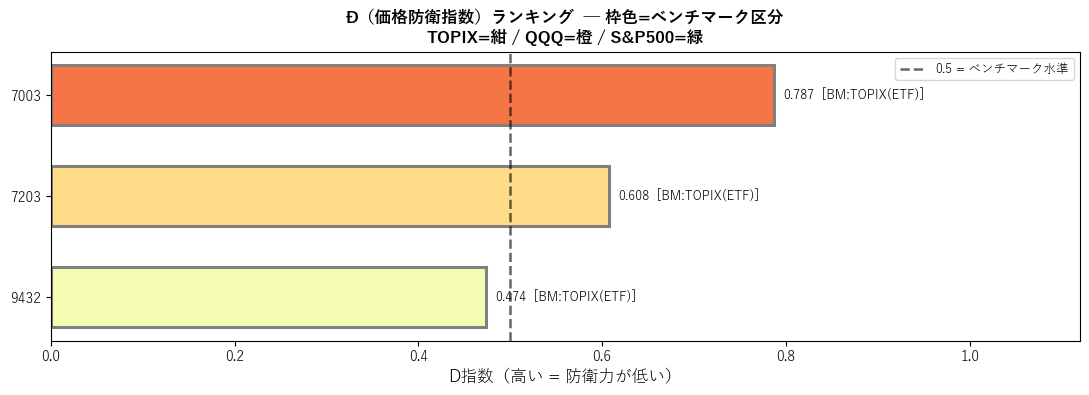

In [8]:
# ---- 7-1. D指数バーチャート（ベンチマーク基準線付き）----
fig, ax = plt.subplots(figsize=(11, max(4, len(price_data) * 0.85 + 1.5)))
sorted_df = norm_df.sort_values('D_index', ascending=False)
colors    = plt.cm.RdYlGn_r(sorted_df['D_index'].values)
bm_colors = {'TOPIX': 'navy', 'QQQ': 'darkorange', 'S&P500': 'darkgreen'}
e_colors  = [bm_colors.get(sorted_df.loc[t, 'Benchmark'], 'gray')
              for t in sorted_df.index]

bars = ax.barh(sorted_df.index, sorted_df['D_index'],
               color=colors, edgecolor=e_colors, linewidth=2.2, height=0.6)
ax.axvline(0.5, color='black', lw=1.8, linestyle='--', alpha=0.6,
           label='0.5 = ベンチマーク水準')
ax.set_xlabel('D指数（高い = 防衛力が低い）', fontsize=12)
ax.set_title('Ð（価格防衛指数）ランキング  ─ 枠色=ベンチマーク区分\n'
             'TOPIX=紺 / QQQ=橙 / S&P500=緑', fontsize=12, fontweight='bold')
ax.set_xlim(0, 1.12)
for bar, val, t in zip(bars, sorted_df['D_index'], sorted_df.index):
    bm = sorted_df.loc[t, 'Benchmark']
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}  [BM:{bm}]', va='center', fontsize=9)
ax.invert_yaxis()
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

KeyError: 'Benchmark'

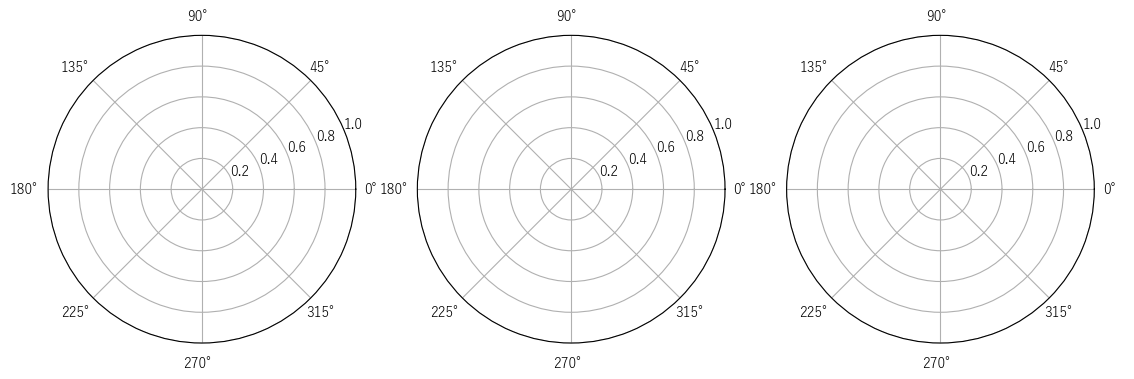

In [12]:
# ---- 7-2. レーダーチャート（6指標 / BM基準線 = 0.5）----
# defensive スコア（反転済み）で描画: 外側 = ディフェンシブ性が高い
labels_r = ['① MA\n固り比率', '② 最大\n下方乖離', '③ 52w安値\n/200MA',
             '④ 最大\nDD', '⑤ 下方\nVol', '⑥ 出来高\n下方圧力']
N      = len(METRIC_COLS)
angles = [n / N * 2 * np.pi for n in range(N)] + [0]
bm_ref = [0.5] * (N + 1)   # ベンチマーク基準ライン

# grade_df から defensive スコア（反転済み）を使う
tickers_plot = list(norm_df.index)
n_t  = len(tickers_plot)
fig, axes = plt.subplots(1, n_t, figsize=(4.5 * n_t, 4.5),
                          subplot_kw=dict(polar=True))
if n_t == 1:
    axes = [axes]

cmap = plt.cm.tab10
for i, (ticker, ax) in enumerate(zip(tickers_plot, axes)):
    # grade_df の指標列はすでに反転済み (1 - norm)
    def_metric_df = 1.0 - norm_df[METRIC_COLS]   # セル内で完結
    vals = def_metric_df.loc[ticker].tolist()
    vals  = vals + [vals[0]]
    bm_lbl = def_metric_df.loc[ticker, 'Benchmark']
    grade  = def_metric_df.loc[ticker, 'Grade']
    def_sc = def_metric_df.loc[ticker, 'defensive_score']
    color  = cmap(i)
    ax.plot(angles, vals, color=color, linewidth=2)
    ax.fill(angles, vals, color=color, alpha=0.25)
    ax.plot(angles, bm_ref, color='gray', lw=1.2,
            linestyle='--', alpha=0.7, label='BM=0.5')
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels_r, fontsize=7.5)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], fontsize=6)
    ax.set_title(
        f'{ticker}  [{grade}]\nDef={def_sc:.3f}  [{bm_lbl}]',
        fontsize=10, fontweight='bold', pad=15
    )

plt.suptitle('6指標プロファイル（外側 = ディフェンシブ性が高い / 破線 = BM = 0.5）',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

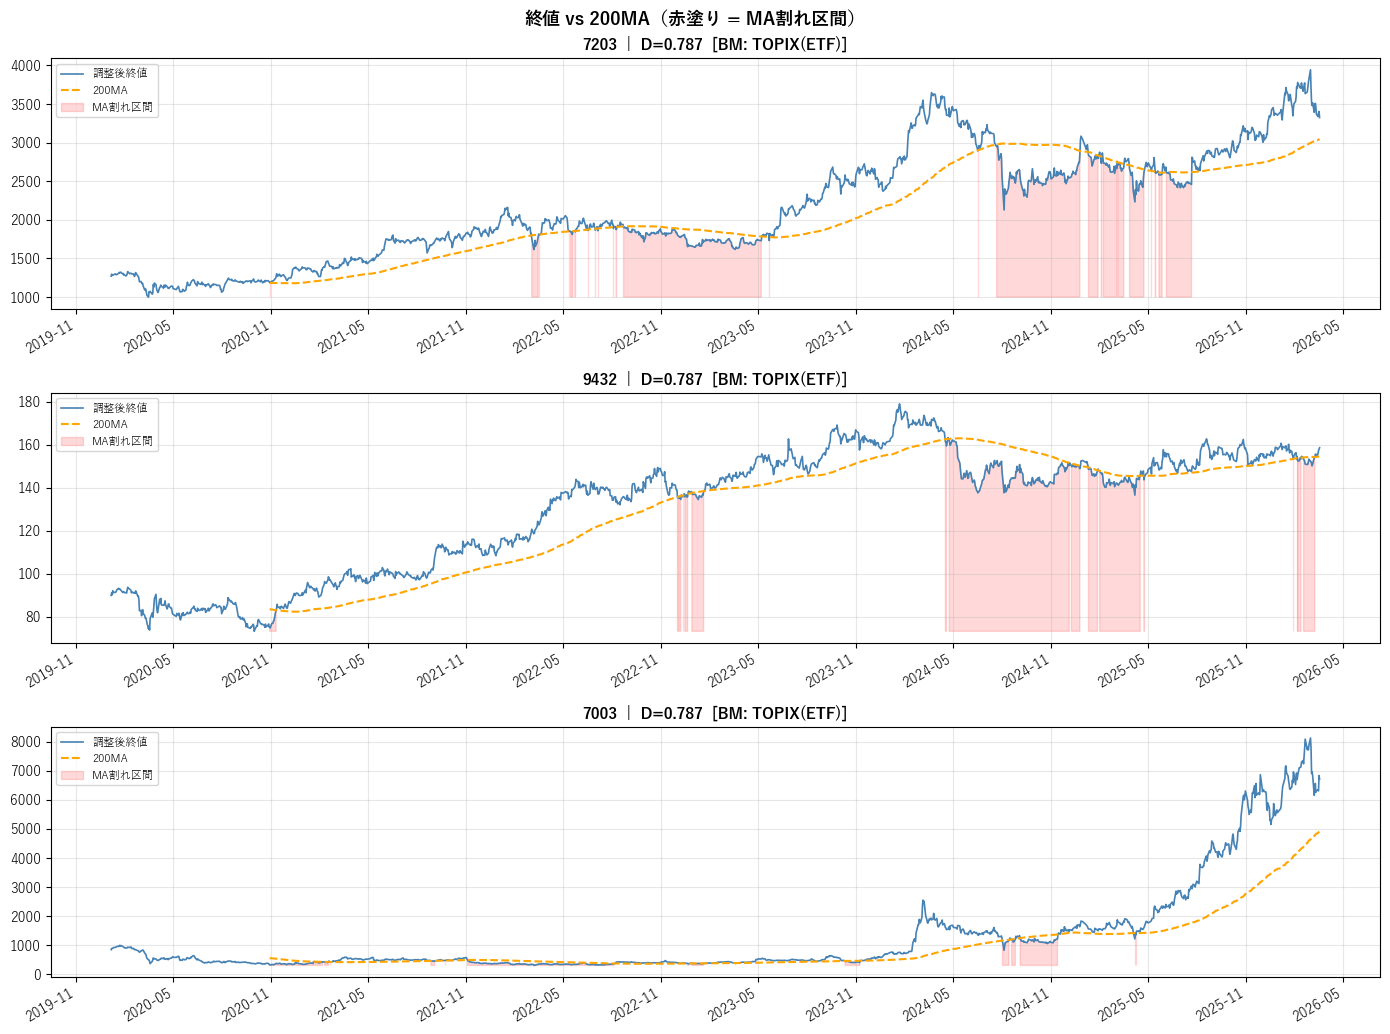

In [17]:
# ---- 7-3. 終値 vs 200MA ----
labels_list = list(price_data.keys())
fig, axes = plt.subplots(len(labels_list), 1,
                          figsize=(14, 3.5 * len(labels_list)), sharex=False)
if len(labels_list) == 1:
    axes = [axes]

for ax, label in zip(axes, labels_list):
    df    = price_data[label]
    ma    = detail_store[label]['ma']
    close = df['Close']
    bm_lbl = detail_store[label]['bm_label']
    def_val = norm_df.loc[label, 'defensive_score']   # 反転済み

    ax.plot(close.index, close, lw=1.2, label='調整後終値', color='steelblue')
    ax.plot(ma.index, ma, lw=1.5, label=f'{MA_PERIOD}MA',
            color='orange', linestyle='--')
    ax.fill_between(close.index, close.min(), close,
                    where=(close < ma), alpha=0.15, color='red', label='MA割れ区間')
    ax.set_title(f'{label}  |  D={d_val:.3f}  [BM: {bm_lbl}]',
                 fontsize=11, fontweight='bold')
    ax.legend(loc='upper left', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.grid(alpha=0.3)

plt.suptitle('終値 vs 200MA（赤塗り = MA割れ区間）', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

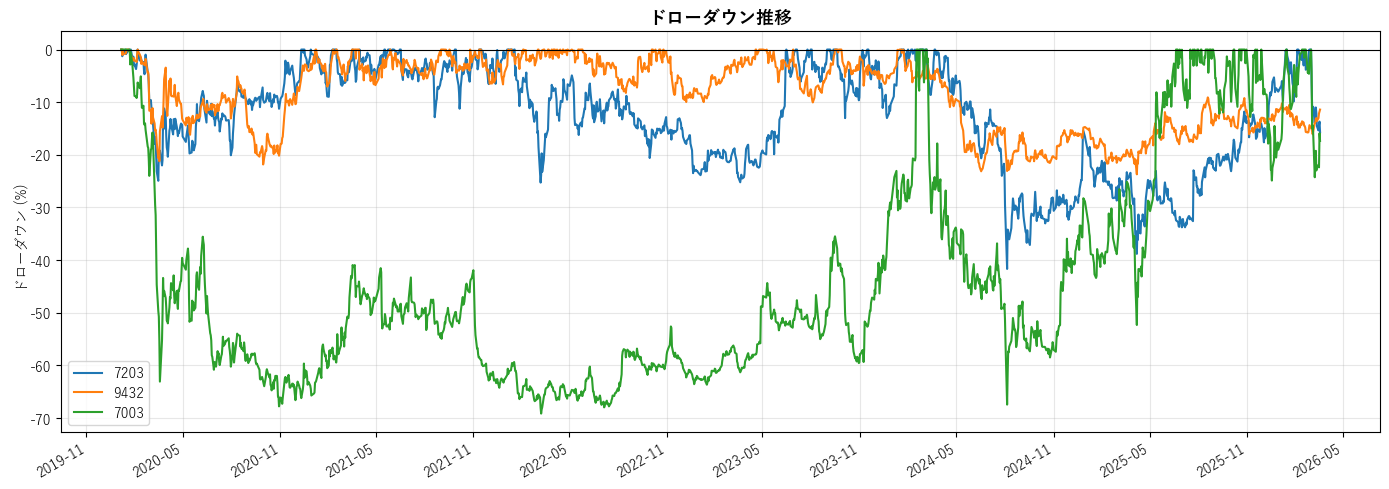

In [11]:
# ---- 7-4. ドローダウン推移 ----
fig, ax = plt.subplots(figsize=(14, 5))
cmap = plt.cm.tab10
for i, label in enumerate(labels_list):
    dd = detail_store[label]['drawdown'] * 100
    ax.plot(dd.index, dd, label=label, color=cmap(i), lw=1.5)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('ドローダウン (%)')
ax.set_title('ドローダウン推移', fontsize=13, fontweight='bold')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

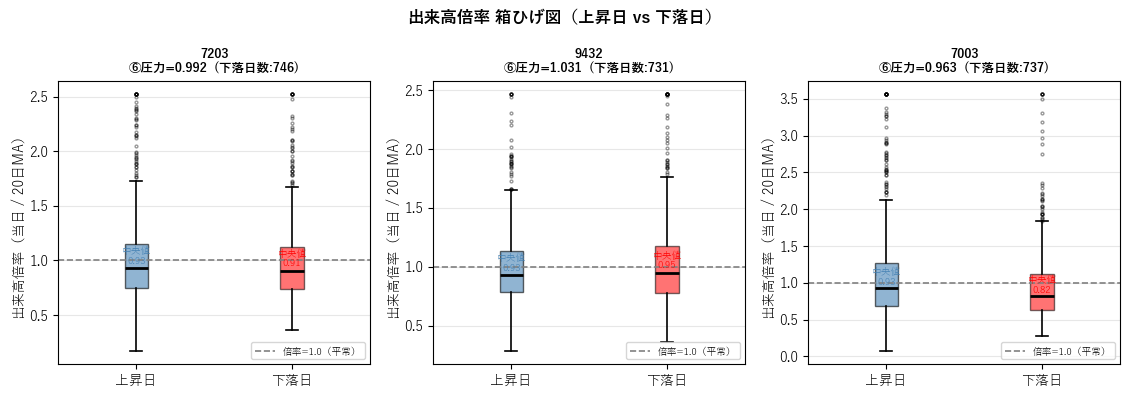

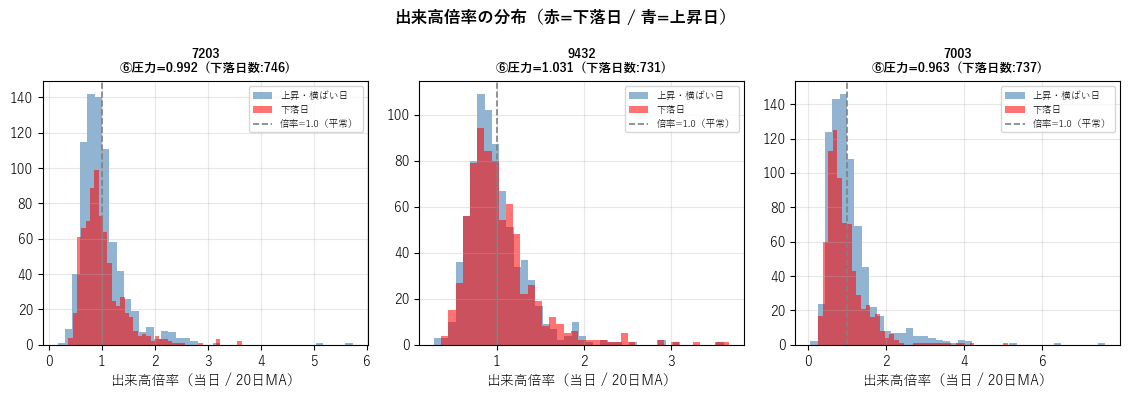

In [22]:
# ------ 前段: 箱ひげ図 ------
labels_list = list(price_data.keys())   # 追加
n_tickers   = len(labels_list)          # 追加

fig_box, axes_box = plt.subplots(1, n_tickers,
                                   figsize=(3.8 * n_tickers, 4))
if n_tickers == 1:
    axes_box = [axes_box]

for ax, label in zip(axes_box, labels_list):
    vr        = detail_store[label]['vol_ratio'].dropna()
    down_mask = detail_store[label]['down_mask']
    down_vr   = vr[down_mask[vr.index]].dropna()
    up_vr     = vr[~down_mask[vr.index]].dropna()

    # 外れ値を除いて見やすくする（99パーセンタイルでクリップ）
    cap = vr.quantile(0.99)
    down_vr_cap = down_vr.clip(upper=cap)
    up_vr_cap   = up_vr.clip(upper=cap)

    bp = ax.boxplot(
        [up_vr_cap, down_vr_cap],
        labels=['上昇日', '下落日'],
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='o', markersize=2, alpha=0.4),
    )
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('red')
    bp['boxes'][1].set_alpha(0.55)

    ax.axhline(1.0, color='gray', lw=1.2, ls='--', label='倍率=1.0（平常）')

    # 中央値をテキストで併記
    med_up   = up_vr.median()
    med_down = down_vr.median()
    ax.text(1, med_up   + 0.03, f'中央値\n{med_up:.2f}',
            ha='center', va='bottom', fontsize=7, color='steelblue')
    ax.text(2, med_down + 0.03, f'中央値\n{med_down:.2f}',
            ha='center', va='bottom', fontsize=7, color='red')

    pres = raw_df.loc[label, '⑥_vol_pressure']
    n    = detail_store[label]['n_down']
    ax.set_title(f'{label}\n⑥圧力={pres:.3f}  (下落日数:{n})',
                 fontsize=9, fontweight='bold')
    ax.set_ylabel(f'出来高倍率（当日 / {VOL_MA_WINDOW}日MA）')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('出来高倍率 箱ひげ図（上昇日 vs 下落日）', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ---- 7-5. 出来高倍率の分布（⑥ 詳細チャート）----
fig, axes = plt.subplots(1, len(labels_list),
                          figsize=(3.8 * len(labels_list), 4))
if len(labels_list) == 1:
    axes = [axes]

for ax, label in zip(axes, labels_list):
    vr         = detail_store[label]['vol_ratio'].dropna()
    down_mask  = detail_store[label]['down_mask']
    down_vr    = vr[down_mask[vr.index]].dropna()
    up_vr      = vr[~down_mask[vr.index]].dropna()

    ax.hist(up_vr,   bins=40, color='steelblue', alpha=0.6, label='上昇・横ばい日')
    ax.hist(down_vr, bins=40, color='red',       alpha=0.55, label='下落日')
    ax.axvline(1.0, color='gray', lw=1.2, ls='--', label='倍率=1.0（平常）')

    pres = raw_df.loc[label, '⑥_vol_pressure']
    n    = detail_store[label]['n_down']
    ax.set_title(f'{label}\n⑥圧力={pres:.3f}  (下落日数:{n})',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel(f'出来高倍率（当日 / {VOL_MA_WINDOW}日MA）')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('出来高倍率の分布（赤=下落日 / 青=上昇日）', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

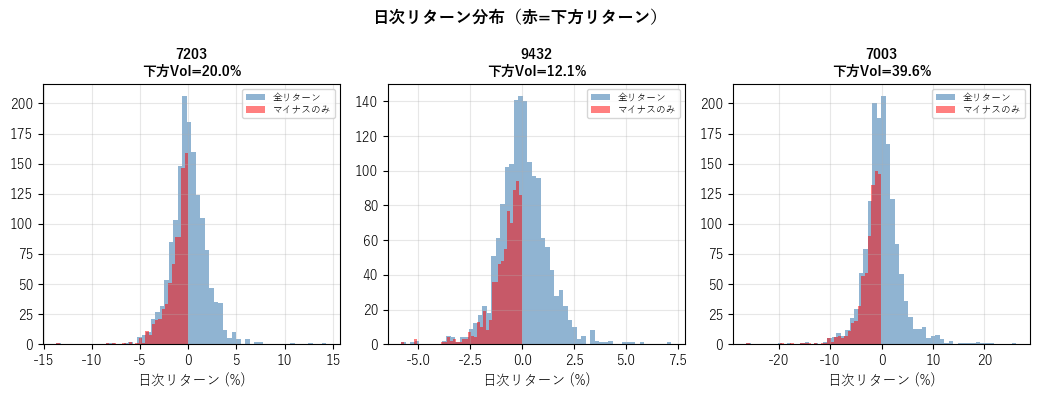

In [13]:
# ---- 7-6. 日次リターン分布 ----
fig, axes = plt.subplots(1, len(labels_list),
                          figsize=(3.5 * len(labels_list), 4))
if len(labels_list) == 1:
    axes = [axes]

for ax, label in zip(axes, labels_list):
    ret     = detail_store[label]['daily_ret'] * 100
    neg_ret = ret[ret < 0]
    ax.hist(ret, bins=60, color='steelblue', alpha=0.6, label='全リターン')
    ax.hist(neg_ret, bins=40, color='red', alpha=0.5, label='マイナスのみ')
    dv = raw_df.loc[label, '⑤_downside_vol'] * 100
    ax.set_title(f'{label}\n下方Vol={dv:.1f}%', fontsize=10, fontweight='bold')
    ax.set_xlabel('日次リターン (%)')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('日次リターン分布（赤=下方リターン）', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. 結果サマリー出力

In [14]:
# ============================================================
# ランク付けロジック
# ============================================================

# ---- ②ランク境界定義 ----
RANK_BOUNDS = [
    ('S', 0.80, 1.01),
    ('A', 0.65, 0.80),
    ('B', 0.50, 0.65),
    ('C', 0.35, 0.50),
    ('D', 0.20, 0.35),
    ('E', 0.00, 0.20),
]
RANK_BOUNDARY_WIDTH = 0.075   # ±この範囲内を境界付近と判定

def get_base_rank(score: float) -> str:
    """②スコアからベースランク(S/A/B/C/D/E)を返す"""
    for rank, lo, hi in RANK_BOUNDS:
        if lo <= score < hi:
            return rank
    return 'E'

def get_rank_center(rank: str) -> float:
    """ランクの中央値を返す"""
    for r, lo, hi in RANK_BOUNDS:
        if r == rank:
            return (lo + hi) / 2 if hi < 1.01 else (lo + 1.0) / 2
    return 0.5

def get_plus_minus(score: float, base_rank: str,
                   metric_scores: pd.Series) -> str:
    """
    ④ +/- 判定（案X: 6指標の分布で判断）

    境界付近（ランク境界から RANK_BOUNDARY_WIDTH 以内）のみ判定。
    各指標スコアを反転（defensive = 1 - normalized）して
    上位ランク寄りの指標が多ければ +、下位ランク寄りが多ければ -。

    S+ / E- は③の仕様により不要なので除外。
    """
    rank_idx = [r for r, _, _ in RANK_BOUNDS]
    cur_idx  = rank_idx.index(base_rank)

    # 上側境界・下側境界からの距離
    _, lo, hi = RANK_BOUNDS[cur_idx]
    near_upper = (hi < 1.01) and (score >= hi - RANK_BOUNDARY_WIDTH)
    near_lower = (lo > 0.00) and (score <  lo + RANK_BOUNDARY_WIDTH)

    if not near_upper and not near_lower:
        # ③中央値: S/E以外は +/B/- の3段階
        # 中央より上側なら+、下側なら-、中央付近は無印
        mid = get_rank_center(base_rank)
        band = (hi - lo) / 6   # ランク幅の1/6をバッファ
        if score >= mid + band:
            if base_rank == 'S':
                return base_rank          # S+ は不要 → S
            return base_rank + '+'
        elif score <= mid - band:
            if base_rank == 'E':
                return base_rank          # E- は不要 → E
            return base_rank + '-'
        else:
            return base_rank

    # ④境界付近: 6指標の分布で +/- を判定
    # 各指標の defensive スコア（1 - norm）でランクを計算
    def_scores = 1.0 - metric_scores   # 指標も反転
    upper_count = 0
    lower_count = 0
    for ms in def_scores:
        ms_rank = get_base_rank(ms)
        ms_idx  = rank_idx.index(ms_rank)
        if ms_idx < cur_idx:    # 上位ランク
            upper_count += 1
        elif ms_idx > cur_idx:  # 下位ランク
            lower_count += 1

    if upper_count > lower_count:
        suffix = '+'
    elif lower_count > upper_count:
        suffix = '-'
    else:
        suffix = ''

    # S+ / E- は不要
    if base_rank == 'S' and suffix == '+':
        suffix = ''
    if base_rank == 'E' and suffix == '-':
        suffix = ''

    return base_rank + suffix


# ============================================================
# 各銘柄にスコア・ランクを付与
# ============================================================
results = []
for label in norm_df.index:
    ds    = norm_df.loc[label, 'defensive_score']
    base  = get_base_rank(ds)
    m_scores = norm_df.loc[label, METRIC_COLS]   # 正規化済み指標スコア
    grade = get_plus_minus(ds, base, m_scores)

    results.append({
        'Ticker':            label,
        'Market':            norm_df.loc[label, 'Market'],
        'Benchmark':         norm_df.loc[label, 'Benchmark'],
        'defensive_score':   round(ds, 4),
        'Grade':             grade,
        **{c: round(1.0 - norm_df.loc[label, c], 3) for c in METRIC_COLS},
    })

grade_df = pd.DataFrame(results).set_index('Ticker')
grade_df = grade_df.sort_values('defensive_score', ascending=False)

# ============================================================
# 表示
# ============================================================
GRADE_ORDER = ['S', 'S-',
               'A+', 'A', 'A-',
               'B+', 'B', 'B-',
               'C+', 'C', 'C-',
               'D+', 'D', 'D-',
               'E+', 'E']

def grade_color(g: str) -> str:
    """グレードに対応する背景色"""
    if g.startswith('S'):   return 'background-color: #1e3a5f; color: #60a5fa'
    if g.startswith('A'):   return 'background-color: #14532d; color: #4ade80'
    if g.startswith('B'):   return 'background-color: #1a2e05; color: #a3e635'
    if g.startswith('C'):   return 'background-color: #422006; color: #fb923c'
    if g.startswith('D'):   return 'background-color: #450a0a; color: #f87171'
    return                         'background-color: #27272a; color: #a1a1aa'

print('=' * 80)
print('  価格ディフェンシブ度 グレード評価')
print('  高い = ディフェンシブ性が高い / 0.5 = ベンチマーク相当')
print('=' * 80)

# グレード付きサマリーテーブル
disp_df = grade_df[['Market', 'Benchmark', 'defensive_score', 'Grade']].copy()
disp_df.columns = ['Market', 'BM', 'Def.Score', 'Grade']
display(disp_df.style
    .format({'Def.Score': '{:.4f}'})
    .applymap(lambda g: grade_color(g), subset=['Grade'])
    .bar(subset=['Def.Score'], color='#22c55e', vmin=0, vmax=1)
)

# 指標別ディフェンシブスコア（反転済み）
print('\n--- 指標別ディフェンシブスコア（高い = 防衛力が高い）---')
metric_disp = grade_df[METRIC_COLS].copy()
metric_disp.columns = ['①MA固り', '②下方乖離', '③52w安値', '④DD', '⑤下方Vol', '⑥出来高圧']
display(metric_disp.style
    .format('{:.3f}')
    .background_gradient(cmap='RdYlGn', axis=0)
)

print(f'\n分析期間    : {START_DATE} ～ {END_DATE}')
print(f'MAウィンドウ: {MA_PERIOD}日  /  出来高MA: {VOL_MA_WINDOW}日')
print(f'重み        : { {k: v for k, v in WEIGHTS.items()} }')
print('\nベンチマーク生値（参考）:')
for market, rv in bm_raw.items():
    bm_lbl = BENCHMARK_LABEL.get(market, market)
    bm_sym = bm_sym_used.get(market, '?')
    print(f'  {bm_lbl:12s} ({bm_sym:8s}): '
          f'MA下回り={rv["①_below_ma_ratio"]:.1%}  '
          f'MDD={rv["④_max_drawdown"]:.1%}  '
          f'下方Vol={rv["⑤_downside_vol"]:.1%}  '
          f'出来高圧力={rv["⑥_vol_pressure"]:.3f}')

  価格ディフェンシブ度 グレード評価
  高い = ディフェンシブ性が高い / 0.5 = ベンチマーク相当


,Market,BM,Def.Score,Grade
Ticker,,,,
9432,JP,TOPIX(ETF),0.5261,B-
7203,JP,TOPIX(ETF),0.3924,C
7003,JP,TOPIX(ETF),0.2131,D-



--- 指標別ディフェンシブスコア（高い = 防衛力が高い）---


,①MA固り,②下方乖離,③52w安値,④DD,⑤下方Vol,⑥出来高圧
Ticker,,,,,,
9432,0.311,0.484,0.642,0.560,0.545,0.658
7203,0.093,0.281,0.531,0.376,0.413,0.809
7003,0.169,0.080,0.148,0.095,0.087,0.919



分析期間    : 2020-01-01 ～ 2026-03-23
MAウィンドウ: 200日  /  出来高MA: 20日
重み        : {'w1_below_ma_ratio': 0.18, 'w2_max_neg_dev': 0.18, 'w3_52w_low_vs_ma': 0.18, 'w4_max_drawdown': 0.22, 'w5_downside_vol': 0.12, 'w6_vol_pressure': 0.12}

ベンチマーク生値（参考）:
  TOPIX(ETF)   (1306.T  ): MA下回り=13.8%  MDD=29.6%  下方Vol=14.8%  出来高圧力=1.072


In [15]:
# CSV エクスポート（オプション）
EXPORT_CSV = True
if EXPORT_CSV:
    out_path = f'd_index_{datetime.today().strftime("%Y%m%d")}.csv'
    export_df = grade_df.copy()
    export_df.to_csv(out_path)
    print(f'✅ CSV保存完了: {out_path}  (defensive_score + Grade + 指標別スコア)')

✅ CSV保存完了: d_index_20260323.csv  (defensive_score + Grade + 指標別スコア)
